 # 3.03 — Logistic Regression Retrain — July 2026 Included

 I now have July 2026 availability data in the training tables, which was missing when
 the previous retrain ran. This notebook retrains all six logistic classifiers on
 2019 + 2021 + May through July 2026, holds August 2026 back for evaluation and
 calibration, and then does a final production fit on all four 2026 months.

 The structure is the same as the previous retrain. The only substantive change is that
 July rows are now present, so the trained models actually have summer 2026 patterns
 in them rather than relying on May and June alone.

In [ ]:
import sys
import time
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, brier_score_loss, roc_curve,
)
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
from threadpoolctl import threadpool_limits

warnings.filterwarnings("ignore", category=UserWarning)

sys.path.insert(0, str(Path().resolve().parent))
from model_training.feature_prep import (
    TARGET_CLASSIFICATION,
    build_preprocessor,
    get_X_y,
    load_training_data,
)

 ## Setup

 Six horizons, same as always. August 2026 is the holdout month. July is now part of
 the training set, which is the whole reason this retrain exists.

 FORCE_RETRAIN controls whether to re-run the expensive training and scoring steps.
 Set it to False once the models are saved and the notebook is committed — re-running
 any cell from there only reloads from disk, so editing charts or descriptions is instant.

In [ ]:
HORIZONS       = [60, 180, 360, 720, 1440, 2880]
HORIZON_LABELS = {60: "1hr", 180: "3hr", 360: "6hr",
                  720: "12hr", 1440: "24hr", 2880: "multi-day"}

FORCE_RETRAIN = True

TRAIN_YEARS   = [2019, 2021]
TRAIN_MONTHS  = ["2026-05", "2026-06", "2026-07"]
HOLDOUT_MONTH = "2026-08"
ALL_MONTHS    = ["2026-05", "2026-06", "2026-07", "2026-08"]

BASE_LOGIT_PARAMS = dict(
    penalty=None, solver="saga", tol=1e-2,
    max_iter=200, class_weight=None, random_state=42, verbose=0,
)

MODELS_DIR  = Path("../models")
REPORTS_DIR = Path("../reports/figures")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Horizons:      {[HORIZON_LABELS[h] for h in HORIZONS]}")
print(f"Train years:   {TRAIN_YEARS}")
print(f"Train months:  {TRAIN_MONTHS}")
print(f"Holdout month: {HOLDOUT_MONTH}")
print(f"Models dir:    {MODELS_DIR.resolve()}")

Horizons:      ['1hr', '3hr', '6hr', '12hr', '24hr', 'multi-day']
Train years:   [2019, 2021]
Train months:  ['2026-05', '2026-06', '2026-07']
Holdout month: 2026-08
Models dir:    C:\Users\clark\Desktop\citibike\models


 ## Helper functions

 Same helpers as before. best_f1_above_base_rate picks the threshold that maximizes
 F1 while keeping precision above the base rate — the point where the model adds value
 over just predicting "always available."

In [ ]:
def best_f1_above_base_rate(precision, recall, base_rate=0.92):
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    mask = precision > base_rate
    if not mask.any():
        return int(np.argmax(f1))
    candidates = np.where(mask)[0]
    return int(candidates[np.argmax(f1[candidates])])


def log_odds_from(prob):
    p = np.clip(prob, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


def print_coef_table(coef_df, label, top_n=20):
    top = coef_df.reindex(coef_df["coef"].abs().nlargest(top_n).index)
    top = top.sort_values("coef", ascending=False)
    top.index.name = "feature"
    top.columns = ["coef", "p_value", "z_score"]
    print(f"\n--- {label} horizon  (top {top_n} by |coef|) ---")
    print(f"{'feature':<55} {'coef':>9} {'z_score':>9} {'p_value':>12}")
    print("-" * 88)
    for feat, row in top.iterrows():
        print(f"{feat:<55} {row['coef']:>9.4f} {row['z_score']:>9.2f} {row['p_value']:>12.4e}")


def fit_statsmodels_logit(h, n_sample=300_000):
    df = load_training_data(h, years=TRAIN_YEARS + [2026])
    m = df["timestamp"].dt.to_period("M").astype(str)
    df = df[(df["timestamp"].dt.year != 2026) | m.isin(TRAIN_MONTHS)]
    X, y = get_X_y(df, TARGET_CLASSIFICATION)
    del df
    pipe_pre = Pipeline([("pre", build_preprocessor("linear"))])
    X_pre = pipe_pre.fit_transform(X, y)
    del X
    if X_pre.shape[0] > n_sample:
        idx = np.random.default_rng(42).choice(X_pre.shape[0], n_sample, replace=False)
        X_s = X_pre[idx]
        y_s = y.iloc[idx].values
    else:
        X_s, y_s = X_pre, y.values
    X_sm = sm.add_constant(X_s, has_constant="add")
    _, R = np.linalg.qr(X_sm)
    keep = np.abs(np.diag(R)) > 1e-10
    X_sm_qr = X_sm[:, keep]
    all_names = ["const"] + pipe_pre.named_steps["pre"].get_feature_names_out().tolist()
    feature_names = [n for n, k in zip(all_names, keep) if k]
    res = sm.Logit(y_s, X_sm_qr).fit(disp=False)
    coef_df = pd.DataFrame({
        "coef":    res.params,
        "pvalue":  res.pvalues,
        "z":       res.tvalues,
    }, index=feature_names[:len(res.params)])
    return coef_df

 ## Train one model per time horizon

 Each horizon gets a separate model because the features that matter shift with how far
 ahead we are predicting. At one hour out, current bike count is almost everything. At
 24 hours out, weather forecast and demand profile dominate. Training them separately
 lets each model learn the right weights for its job.

 Expected runtime is roughly 25-33 minutes per horizon, about 3 hours total. This cell
 is skipped entirely when FORCE_RETRAIN=False and the model files already exist.

In [ ]:
_models_exist = all(
    (MODELS_DIR / f"logistic_classification_{h}min.joblib").exists()
    for h in HORIZONS
)

if FORCE_RETRAIN or not _models_exist:
    trained_models = {}
    for h in HORIZONS:
        label = HORIZON_LABELS[h]
        t0 = time.time()

        df = load_training_data(h, years=TRAIN_YEARS + [2026])
        m = df["timestamp"].dt.to_period("M").astype(str)
        df = df[(df["timestamp"].dt.year != 2026) | m.isin(TRAIN_MONTHS)]
        X, y = get_X_y(df, TARGET_CLASSIFICATION)
        y = y.astype("int8")
        num_cols = X.select_dtypes(include=["float64"]).columns
        X[num_cols] = X[num_cols].astype("float32")
        base_rate = float(np.mean(y))
        print(f"  {label:<10} {len(X):>11,} rows  base rate {base_rate:.4f}  fitting ...",
              end=" ", flush=True)
        del df

        pipe = Pipeline([
            ("pre",   build_preprocessor("linear")),
            ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
        ])
        with threadpool_limits(limits=28):
            pipe.fit(X, y)

        out = MODELS_DIR / f"logistic_classification_{h}min.joblib"
        joblib.dump(pipe, out)
        print(f"saved -> {out.name}   ({time.time() - t0:.0f}s)")
        trained_models[h] = pipe
        del X, y, pipe
else:
    trained_models = {
        h: joblib.load(MODELS_DIR / f"logistic_classification_{h}min.joblib")
        for h in HORIZONS
    }
    print("Loaded existing models from disk (FORCE_RETRAIN=False)")

  1hr         16,504,387 rows  base rate 0.9353  fitting ... saved -> logistic_classification_60min.joblib   (1569s)
  3hr         16,185,449 rows  base rate 0.9352  fitting ... saved -> logistic_classification_180min.joblib   (1082s)
  6hr         15,837,738 rows  base rate 0.9356  fitting ... saved -> logistic_classification_360min.joblib   (1103s)
  12hr        15,552,708 rows  base rate 0.9348  fitting ... saved -> logistic_classification_720min.joblib   (1181s)
  24hr        16,510,413 rows  base rate 0.9357  fitting ... saved -> logistic_classification_1440min.joblib   (1160s)
  multi-day   16,306,024 rows  base rate 0.9355  fitting ... saved -> logistic_classification_2880min.joblib   (1202s)


 ## Score August 2026 — the holdout month

 Now I run each trained model against August 2026, which the models have never seen.
 The output is a raw probability per station-hour: how likely is it that at least one
 bike is available? These probabilities feed into the evaluation and calibration below.

 When FORCE_RETRAIN=False, this cell loads from the saved .npz file so charts can be
 edited and re-run without re-scoring.

In [ ]:
_scores_file = REPORTS_DIR / "3.03_holdout_scores.npz"

if FORCE_RETRAIN or not _scores_file.exists():
    holdout_results = {}
    for h in HORIZONS:
        df_h = load_training_data(h, years=[2026])
        df_h = df_h[(df_h["timestamp"].dt.year == 2026) & (df_h["timestamp"].dt.month == 8)]
        X_h, y_h = get_X_y(df_h, TARGET_CLASSIFICATION)
        raw_prob = trained_models[h].predict_proba(X_h)[:, 1]
        holdout_results[h] = {"y_true": y_h.values, "raw_prob": raw_prob}
        print(f"  {HORIZON_LABELS[h]:<10} {len(y_h):,} holdout rows scored")
        del df_h, X_h

    np.savez(
        str(_scores_file),
        **{f"y_{h}": r["y_true"] for h, r in holdout_results.items()},
        **{f"p_{h}": r["raw_prob"] for h, r in holdout_results.items()},
    )
    print(f"Saved holdout scores -> {_scores_file.name}")
else:
    data = np.load(_scores_file)
    holdout_results = {
        h: {"y_true": data[f"y_{h}"], "raw_prob": data[f"p_{h}"]}
        for h in HORIZONS
    }
    print("Loaded holdout scores from disk (FORCE_RETRAIN=False)")

  1hr        1,835,502 holdout rows scored
  3hr        1,825,450 holdout rows scored
  6hr        1,810,372 holdout rows scored
  12hr       1,795,264 holdout rows scored
  24hr       1,765,053 holdout rows scored
  multi-day  1,704,630 holdout rows scored
Saved holdout scores -> 3.03_holdout_scores.npz


 ## How well does each model perform?

 The dataset is heavily imbalanced: roughly 92% of station-hours have at least one bike.
 A naive classifier that always predicts "available" would score ~0.92 on Average
 Precision, so every metric needs to be read against that baseline.

 Four metrics per horizon, each with its naive-baseline value:
 - AP (PR-AUC): area under the precision-recall curve. Baseline = base rate (~0.92).
 - ROC-AUC: discrimination quality, threshold-independent. Baseline = 0.50.
 - F1 at best threshold: maximized subject to precision staying above the base rate.
 - Brier score: mean squared error of probabilities. Baseline = BR*(1-BR) (~0.074).

In [ ]:
_metrics_file = REPORTS_DIR / "3.03_ap_metrics.csv"

if FORCE_RETRAIN or not _metrics_file.exists():
    rows = []
    for h in HORIZONS:
        r = holdout_results[h]
        base_rate = float(np.mean(r["y_true"]))

        ap  = average_precision_score(r["y_true"], r["raw_prob"])
        auc = roc_auc_score(r["y_true"], r["raw_prob"])
        brier = brier_score_loss(r["y_true"], r["raw_prob"])

        prec, rec, thresh = precision_recall_curve(r["y_true"], r["raw_prob"])
        best_idx = best_f1_above_base_rate(prec, rec, base_rate=base_rate)
        f1 = 2 * prec[best_idx] * rec[best_idx] / (prec[best_idx] + rec[best_idx])

        baseline_ap    = base_rate
        baseline_auc   = 0.50
        baseline_f1    = 2 * base_rate / (1 + base_rate)
        baseline_brier = base_rate * (1 - base_rate)

        rows.append({
            "horizon": h, "label": HORIZON_LABELS[h],
            "base_rate": base_rate,
            "ap": ap,       "baseline_ap": baseline_ap,
            "auc": auc,     "baseline_auc": baseline_auc,
            "f1": f1,       "baseline_f1": baseline_f1,
            "brier": brier, "baseline_brier": baseline_brier,
        })
        print(f"  {HORIZON_LABELS[h]:<10}  base rate {base_rate:.4f}")
        print(f"    AP     {ap:.4f}  (baseline {baseline_ap:.4f}, "
              f"{ap - baseline_ap:+.4f})")
        print(f"    AUC    {auc:.4f}  (baseline {baseline_auc:.4f}, "
              f"{auc - baseline_auc:+.4f})")
        print(f"    F1     {f1:.4f}  (baseline {baseline_f1:.4f}, "
              f"{f1 - baseline_f1:+.4f})")
        print(f"    Brier  {brier:.4f}  (baseline {baseline_brier:.4f}, "
              f"{brier - baseline_brier:+.4f})")

    pd.DataFrame(rows).to_csv(_metrics_file, index=False)
    print(f"\nSaved metrics -> {_metrics_file.name}")
else:
    df_m = pd.read_csv(_metrics_file)
    for _, row in df_m.iterrows():
        print(f"  {row['label']:<10}  base rate {row['base_rate']:.4f}")
        print(f"    AP     {row['ap']:.4f}  (baseline {row['baseline_ap']:.4f}, "
              f"{row['ap'] - row['baseline_ap']:+.4f})")
        print(f"    AUC    {row['auc']:.4f}  (baseline {row['baseline_auc']:.4f}, "
              f"{row['auc'] - row['baseline_auc']:+.4f})")
        print(f"    F1     {row['f1']:.4f}  (baseline {row['baseline_f1']:.4f}, "
              f"{row['f1'] - row['baseline_f1']:+.4f})")
        print(f"    Brier  {row['brier']:.4f}  (baseline {row['baseline_brier']:.4f}, "
              f"{row['brier'] - row['baseline_brier']:+.4f})")
    print("Loaded metrics from disk (FORCE_RETRAIN=False)")

  1hr         base rate 0.9258
    AP     0.9971  (baseline 0.9258, +0.0713)
    AUC    0.9726  (baseline 0.5000, +0.4726)
    F1     0.9811  (baseline 0.9615, +0.0197)
    Brier  0.0302  (baseline 0.0687, -0.0385)
  3hr         base rate 0.9259
    AP     0.9933  (baseline 0.9259, +0.0674)
    AUC    0.9403  (baseline 0.5000, +0.4403)
    F1     0.9778  (baseline 0.9615, +0.0163)
    Brier  0.0389  (baseline 0.0686, -0.0297)
  6hr         base rate 0.9260
    AP     0.9902  (baseline 0.9260, +0.0642)
    AUC    0.9181  (baseline 0.5000, +0.4181)
    F1     0.9770  (baseline 0.9616, +0.0154)
    Brier  0.0426  (baseline 0.0685, -0.0259)
  12hr        base rate 0.9260
    AP     0.9904  (baseline 0.9260, +0.0645)
    AUC    0.9210  (baseline 0.5000, +0.4210)
    F1     0.9770  (baseline 0.9616, +0.0154)
    Brier  0.0420  (baseline 0.0686, -0.0266)
  24hr        base rate 0.9259
    AP     0.9898  (baseline 0.9259, +0.0638)
    AUC    0.9119  (baseline 0.5000, +0.4119)
    F1     0.9762

 ## ROC curves — all 6 horizons

 Each curve shows the tradeoff between true positive rate and false positive rate as the
 probability threshold moves from 0 to 1. The area under the curve summarizes how well
 the model separates available from empty stations before I pick any cutoff.

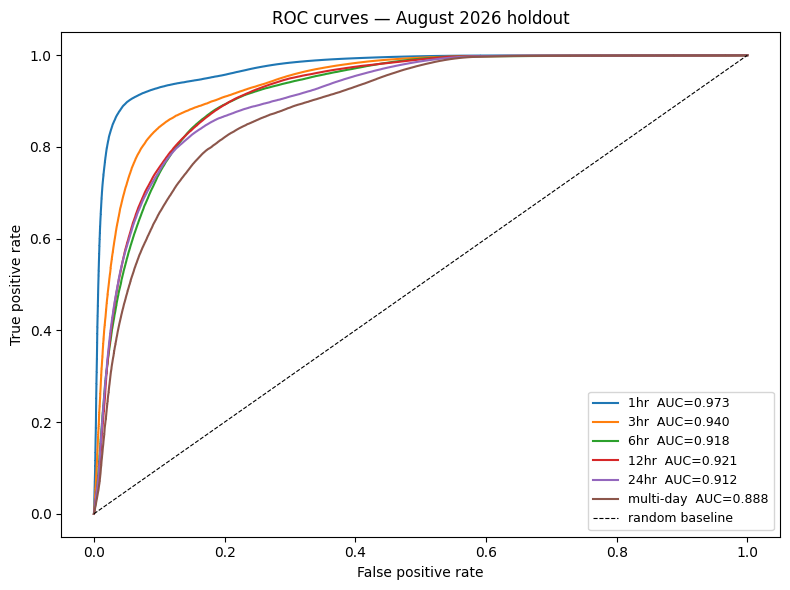

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for h in HORIZONS:
    r = holdout_results[h]
    fpr, tpr, _ = roc_curve(r["y_true"], r["raw_prob"])
    auc = roc_auc_score(r["y_true"], r["raw_prob"])
    ax.plot(fpr, tpr, label=f"{HORIZON_LABELS[h]}  AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random baseline")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — August 2026 holdout")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.03_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## Precision-recall curves — all 6 horizons

 With a 92% base rate, the ROC curve is optimistic. The precision-recall curve is more
 honest. Precision is what fraction of stations flagged as available actually have bikes.
 Recall is what fraction of all genuinely available stations were caught. The dashed line
 is the base rate — any curve above it is adding real value.

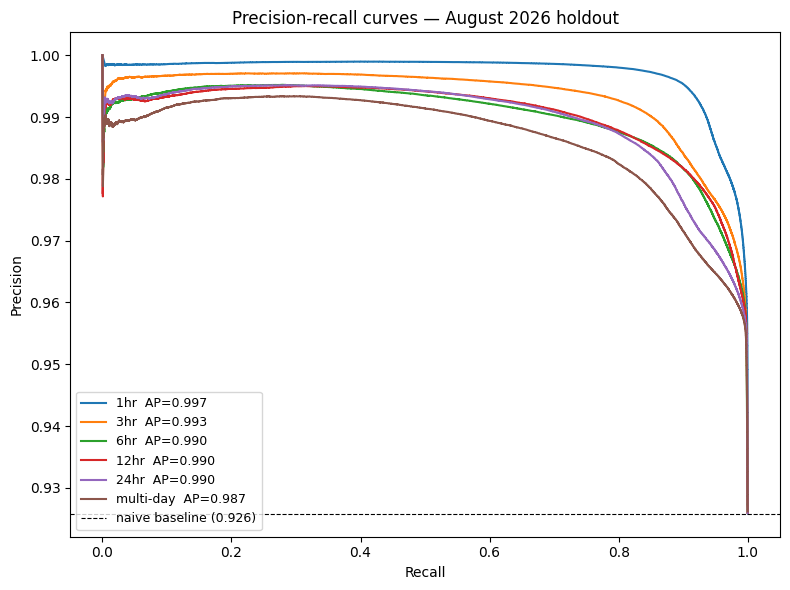

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for h in HORIZONS:
    r = holdout_results[h]
    prec, rec, _ = precision_recall_curve(r["y_true"], r["raw_prob"])
    ap = average_precision_score(r["y_true"], r["raw_prob"])
    ax.plot(rec, prec, label=f"{HORIZON_LABELS[h]}  AP={ap:.3f}")
base_rate = float(np.mean(holdout_results[60]["y_true"]))
ax.axhline(base_rate, color="k", linestyle="--", linewidth=0.8,
           label=f"naive baseline ({base_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves — August 2026 holdout")
ax.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.03_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## What features drive each prediction?

 Logistic regression assigns a weight to each input feature. I fit a separate
 statsmodels logit on a 300,000-row sample to get stable coefficient estimates with
 z-scores and p-values. The QR collinearity check drops any features that cause the
 design matrix to be rank-deficient.

In [ ]:
for h in HORIZONS:
    _coef_file = REPORTS_DIR / f"3.03_logit_coefficients_{HORIZON_LABELS[h]}.csv"
    if FORCE_RETRAIN or not _coef_file.exists():
        coef_df = fit_statsmodels_logit(h, n_sample=300_000)
        coef_df.to_csv(_coef_file)
    else:
        coef_df = pd.read_csv(_coef_file, index_col=0)
    print_coef_table(coef_df, label=HORIZON_LABELS[h])


--- 1hr horizon  (top 20 by |coef|) ---
feature                                                      coef   z_score      p_value
----------------------------------------------------------------------------------------
avg_arrivals_this_hour_dow                               112.0496      3.16   1.5905e-03
rain                                                      69.9381      0.11   9.1417e-01
avg_net_flow_this_hour_dow                                63.2569      3.16   1.5976e-03
snowfall                                                   8.1524      0.11   9.1421e-01
const                                                      7.8297     73.99   0.0000e+00
num_bikes_available                                        5.4212     40.13   0.0000e+00
fill_ratio                                                 1.4930     14.14   2.0955e-45
num_ebikes_available                                       0.7439     10.01   1.4372e-23
apparent_temperature                                       0.6662    

 ## Calibrate the probabilities (Platt scaling)

 Platt scaling fits a two-parameter sigmoid on top of the raw model scores using the
 August holdout rows. After calibration, when the model says 70%, roughly 70% of those
 station-hours genuinely had a bike. The scaler is fit on holdout data to keep the
 calibration honest.

In [ ]:
_scalers_file = MODELS_DIR / "logistic_platt_scalers.joblib"
_calib_file   = REPORTS_DIR / "3.03_calibration.csv"

if FORCE_RETRAIN or not _scalers_file.exists():
    platt_scalers = {}
    calib_rows = []
    for h in HORIZONS:
        r = holdout_results[h]
        log_odds = log_odds_from(r["raw_prob"]).reshape(-1, 1)
        scaler = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs")
        scaler.fit(log_odds, r["y_true"])
        platt_scalers[h] = scaler
        cal_prob = scaler.predict_proba(log_odds)[:, 1]
        b_before = brier_score_loss(r["y_true"], r["raw_prob"])
        b_after  = brier_score_loss(r["y_true"], cal_prob)
        calib_rows.append({"horizon": h, "label": HORIZON_LABELS[h],
                           "brier_before": b_before, "brier_after": b_after})
        print(f"  {HORIZON_LABELS[h]:<10}  Brier before {b_before:.4f}  after {b_after:.4f}")
    joblib.dump(platt_scalers, _scalers_file)
    pd.DataFrame(calib_rows).to_csv(_calib_file, index=False)
    print(f"Saved Platt scalers -> {_scalers_file.name}")
else:
    platt_scalers = joblib.load(_scalers_file)
    df_c = pd.read_csv(_calib_file)
    for _, row in df_c.iterrows():
        print(f"  {row['label']:<10}  Brier before {row['brier_before']:.4f}  "
              f"after {row['brier_after']:.4f}")
    print("Loaded Platt scalers from disk (FORCE_RETRAIN=False)")

  1hr         Brier before 0.0302  after 0.0277
  3hr         Brier before 0.0389  after 0.0352
  6hr         Brier before 0.0426  after 0.0376
  12hr        Brier before 0.0420  after 0.0374
  24hr        Brier before 0.0442  after 0.0410
  multi-day   Brier before 0.0474  after 0.0435
Saved Platt scalers -> logistic_platt_scalers.joblib


 ## Calibration curves — after Platt scaling

 A well-calibrated model means that when it outputs 70%, approximately 70% of those
 station-hours actually had a bike. The closer each line hugs the diagonal, the better
 calibrated that horizon is.

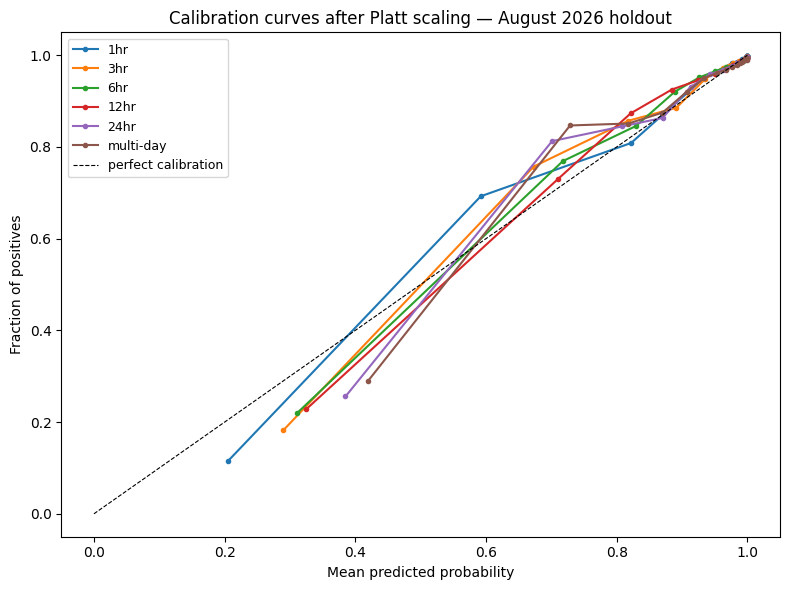

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
for i, h in enumerate(HORIZONS):
    r = holdout_results[h]
    cal_prob = platt_scalers[h].predict_proba(
        log_odds_from(r["raw_prob"]).reshape(-1, 1))[:, 1]
    frac_pos, mean_pred = calibration_curve(
        r["y_true"], cal_prob, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=3,
            color=colors[i], label=HORIZON_LABELS[h])
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curves after Platt scaling — August 2026 holdout")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "3.03_calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 ## Update the probability thresholds

 The scoring script uses a threshold per horizon to flag stations as likely available.
 These thresholds come from the precision-recall sweep below: the probability cutoff where
 F1 is maximized subject to precision staying above the 92% base rate.

 After running this cell, copy the printed PLATT_THRESHOLDS dict into
 model_training/score_stations.py.

In [ ]:
_thresh_file = REPORTS_DIR / "3.03_thresholds.json"

if FORCE_RETRAIN or not _thresh_file.exists():
    new_thresholds = {}
    for h in HORIZONS:
        r = holdout_results[h]
        cal_prob = platt_scalers[h].predict_proba(
            log_odds_from(r["raw_prob"]).reshape(-1, 1))[:, 1]
        prec, rec, thresh = precision_recall_curve(r["y_true"], cal_prob)
        best_idx = best_f1_above_base_rate(prec, rec, base_rate=float(np.mean(r["y_true"])))
        f1_at_best = 2 * prec[best_idx] * rec[best_idx] / (prec[best_idx] + rec[best_idx])
        new_thresholds[h] = round(float(thresh[best_idx]), 2)
        print(f"  {HORIZON_LABELS[h]:<10} threshold={new_thresholds[h]:.2f}  "
              f"prec={prec[best_idx]:.3f}  recall={rec[best_idx]:.3f}  "
              f"f1={f1_at_best:.3f}")
    _thresh_file.write_text(json.dumps({str(k): v for k, v in new_thresholds.items()}))
    print(f"\nSaved thresholds -> {_thresh_file.name}")
else:
    new_thresholds = {int(k): v
                     for k, v in json.loads(_thresh_file.read_text()).items()}
    for h in HORIZONS:
        print(f"  {HORIZON_LABELS[h]:<10} threshold={new_thresholds[h]:.2f}")
    print("Loaded thresholds from disk (FORCE_RETRAIN=False)")

print("\nUpdate PLATT_THRESHOLDS in model_training/score_stations.py:")
print(new_thresholds)

  1hr        threshold=0.45  prec=0.971  recall=0.991  f1=0.981
  3hr        threshold=0.49  prec=0.962  recall=0.994  f1=0.978
  6hr        threshold=0.48  prec=0.959  recall=0.995  f1=0.977
  12hr       threshold=0.47  prec=0.958  recall=0.996  f1=0.977
  24hr       threshold=0.49  prec=0.957  recall=0.997  f1=0.976
  multi-day  threshold=0.52  prec=0.956  recall=0.996  f1=0.976

Saved thresholds -> 3.03_thresholds.json

Update PLATT_THRESHOLDS in model_training/score_stations.py:
{60: 0.45, 180: 0.49, 360: 0.48, 720: 0.47, 1440: 0.49, 2880: 0.52}


 ## Final production fit — all data including August

 The evaluation models above were trained without August so the performance numbers
 are honest. This step retrains each model on the full dataset including August, using
 the same hyperparameters. The Platt scalers from the holdout step carry over unchanged.

In [ ]:
_prod_models_exist = all(
    (MODELS_DIR / f"logistic_classification_{h}min.joblib").exists()
    for h in HORIZONS
)

if FORCE_RETRAIN or not _prod_models_exist:
    print("Final production fit on 2019 + 2021 + May-Aug 2026 ...")
    for h in HORIZONS:
        t0 = time.time()
        df = load_training_data(h, years=TRAIN_YEARS + [2026])
        m = df["timestamp"].dt.to_period("M").astype(str)
        df = df[(df["timestamp"].dt.year != 2026) | m.isin(ALL_MONTHS)]
        X, y = get_X_y(df, TARGET_CLASSIFICATION)
        y = y.astype("int8")
        num_cols = X.select_dtypes(include=["float64"]).columns
        X[num_cols] = X[num_cols].astype("float32")
        print(f"  {HORIZON_LABELS[h]:<10} {len(X):>11,} rows  fitting ...",
              end=" ", flush=True)
        del df

        pipe = Pipeline([
            ("pre",   build_preprocessor("linear")),
            ("model", LogisticRegression(**BASE_LOGIT_PARAMS)),
        ])
        with threadpool_limits(limits=28):
            pipe.fit(X, y)
        out = MODELS_DIR / f"logistic_classification_{h}min.joblib"
        joblib.dump(pipe, out)
        print(f"saved -> {out.name}   ({time.time() - t0:.0f}s)")
        del X, y, pipe

    joblib.dump(platt_scalers, MODELS_DIR / "logistic_platt_scalers.joblib")
    print("Platt scalers saved.")
else:
    print("Production models already on disk (FORCE_RETRAIN=False)")

Final production fit on 2019 + 2021 + May-Aug 2026 ...
  1hr         18,339,889 rows  fitting ... saved -> logistic_classification_60min.joblib   (1848s)
  3hr         18,010,899 rows  fitting ... saved -> logistic_classification_180min.joblib   (1376s)
  6hr         17,648,110 rows  fitting ... saved -> logistic_classification_360min.joblib   (1327s)
  12hr        17,347,972 rows  fitting ... saved -> logistic_classification_720min.joblib   (1404s)
  24hr        18,275,466 rows  fitting ... saved -> logistic_classification_1440min.joblib   (1462s)
  multi-day   18,010,654 rows  fitting ... saved -> logistic_classification_2880min.joblib   (1454s)
Platt scalers saved.


 ## Sanity check — does everything load and produce a prediction?

 Before calling this done, I load every saved artifact and run one August row through
 each model. Anything broken — a missing file, a wrong shape, a pipeline that fails to
 predict — shows up here rather than when the hourly scoring job runs.

In [ ]:
print("Verifying all 6 logistic artifacts ...")
df_demo = load_training_data(60, years=[2026])
df_demo = df_demo[df_demo["timestamp"].dt.to_period("M").astype(str) == "2026-08"]
x_one = get_X_y(df_demo, TARGET_CLASSIFICATION)[0].iloc[[0]]
del df_demo

ok = 0
for h in HORIZONS:
    clf   = joblib.load(MODELS_DIR / f"logistic_classification_{h}min.joblib")
    raw_p = float(clf.predict_proba(x_one)[0, 1])
    cal_p = float(platt_scalers[h].predict_proba(
        log_odds_from(np.array([raw_p])).reshape(-1, 1))[0, 1])
    print(f"  {HORIZON_LABELS[h]:<10} raw P(bike) {raw_p:.3f} -> calibrated {cal_p:.3f}")
    ok += 1

print(f"\nAll {ok} artifacts loaded and produced a prediction.")
print("\nNext step: copy the PLATT_THRESHOLDS dict printed above into "
      "model_training/score_stations.py.")

Verifying all 6 logistic artifacts ...
  1hr        raw P(bike) 0.999 -> calibrated 1.000
  3hr        raw P(bike) 0.995 -> calibrated 0.998
  6hr        raw P(bike) 0.991 -> calibrated 0.997
  12hr       raw P(bike) 0.982 -> calibrated 0.991
  24hr       raw P(bike) 0.986 -> calibrated 0.991
  multi-day  raw P(bike) 0.974 -> calibrated 0.983

All 6 artifacts loaded and produced a prediction.

Next step: copy the PLATT_THRESHOLDS dict printed above into model_training/score_stations.py.


 ## Conclusion

 I retrained all six logistic classifiers on 2019 + 2021 + May through July 2026,
 holding August back for evaluation and Platt calibration. July was the key addition
 this time around. The six pipelines are saved to models/ and the calibrated scalers
 are saved to models/logistic_platt_scalers.joblib.

 The only follow-up step is to copy the PLATT_THRESHOLDS dict printed by the threshold
 cell into model_training/score_stations.py. Nothing else in the codebase needs to change.